# Homework 5 - Problem 2: Fine-Tuning Pretrained Swin Transformers vs. Training from Scratch

**Read this before running:**

1. **Fixes the crash you hit.** `SwinForImageClassification.from_pretrained("microsoft/swin-small-patch4-window7-224", ...)`
   failed with:
   `ValueError: Due to a serious vulnerability issue in torch.load ... upgrade torch to at least v2.6`
   This is `transformers` refusing to load a checkpoint through `torch.load`'s pickle path unless
   `torch >= 2.6.0` - a real fix for a real RCE vulnerability (CVE-2025-32434), not a bug in your code.
   Swin-Tiny's repo ships a `model.safetensors` file (the safe path, no `torch.load` needed), which is
   why it loaded fine; Swin-Small apparently needed the `.bin` fallback, which triggered the block.
   **Fix (do this in your `cifar_env` before re-running):**
   ```
   pip install --upgrade torch torchvision torchaudio
   ```
   Do **not** follow forum posts that monkeypatch `check_torch_load_is_safe()` to bypass this - that
   just reopens the exact RCE hole the check exists to close.

2. **The "from scratch" Swin model has been rewritten.** The previous version's `WindowAttention` did
   full self-attention over every patch with no window partitioning at all - it was a relabeled ViT
   block, not a Swin block. The rewrite below actually implements window partitioning, shifted-window
   attention with the correct attention mask, and patch merging (the two things that make Swin *Swin*).
   It's still deliberately small (2 stages) to stay practical on CIFAR's 32x32 images.

3. **Preprocessing assumption for the scratch model** - flagged where it matters below. The assignment
   says to use "the same preprocessing" for the scratch model; this could mean matching the 224x224
   resize used for the pretrained models, or matching Problem 1's native 32x32 CIFAR pipeline. This
   notebook assumes the latter (with reasoning given inline) - double check this is what your professor
   wants, or explicitly state the assumption in your report either way.

4. Added a fixed random seed (7), per-epoch timing/accuracy tracking (missing before - `train_model`
   only ever returned a final accuracy, never training time), and both trainable **and** total parameter
   counts for all three models (previously only computed for Swin-Tiny, and only the trainable count).


In [7]:
# Force-reinstall PyTorch on a CUDA index that actually ships torch >= 2.6
# (cu121 tops out around torch 2.5.x, which is why Swin-Small still hit the
# CVE-2025-32434 block even after "upgrading" - Swin-Tiny only worked because
# its checkpoint has a .safetensors file that skips the blocked code path)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 --force-reinstall

# Install transformers, thop, and fix the tqdm warning
%pip install transformers thop ipywidgets

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 62.7 MB/s eta 0:00:42
    --------------------------------------- 0.0/2.6 GB 87.8 MB/s eta 0:00:30
    -----------------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import SwinForImageClassification

# 1. Setup Seeds and GPU Device Detection
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data pipeline

In [3]:
def get_dataloaders(resize_to_224=False):
    """Pretrained Swin (window7-224) requires 224x224 inputs; the scratch model runs natively at 32x32."""
    base_transforms = [
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ]

    if resize_to_224:
        train_t = transforms.Compose([transforms.Resize((224, 224)), *base_transforms])
        test_t = transforms.Compose([transforms.Resize((224, 224)), *base_transforms])
    else:
        train_t = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(), *base_transforms])
        test_t = transforms.Compose([*base_transforms])

    train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_t)
    test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=test_t)

    return (DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2),
            DataLoader(test_set, batch_size=32, shuffle=False, num_workers=2))


## 2. Swin Transformer from scratch

Implements the actual defining features of Swin: non-overlapping window attention, a shifted-window
variant every other block (with the correct attention mask so patches can't illegally attend across
the cyclic-shift wrap-around), and patch merging between stages (2x2 neighbor concat + linear
projection, halving resolution and doubling channels - same as the original paper).

In [4]:
def window_partition(x, window_size):
    # x: (B, H, W, C) -> (num_windows*B, window_size, window_size, C)
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows, window_size, H, W):
    # windows: (num_windows*B, window_size, window_size, C) -> (B, H, W, C)
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


def build_shift_mask(H, W, window_size, shift_size, device):
    """Standard Swin attention mask preventing cross-boundary attention after the cyclic shift."""
    img_mask = torch.zeros((1, H, W, 1), device=device)
    h_slices = (slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))
    w_slices = (slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1
    mask_windows = window_partition(img_mask, window_size).view(-1, window_size * window_size)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
    return attn_mask  # (num_windows, N, N)


class WindowAttention(nn.Module):
    """Self-attention computed independently within each (possibly shifted) window."""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, mask=None):
        # x: (num_windows*B, N, C), N = window_size*window_size
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(x)


class SwinBlock(nn.Module):
    def __init__(self, dim, resolution, num_heads, window_size, shift_size):
        super().__init__()
        self.H, self.W = resolution
        self.window_size = window_size
        self.shift_size = shift_size
        # if the feature map is no bigger than one window, there's nothing to partition/shift
        if min(self.H, self.W) <= window_size:
            self.shift_size = 0
            self.window_size = min(self.H, self.W)

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))

        if self.shift_size > 0:
            mask = build_shift_mask(self.H, self.W, self.window_size, self.shift_size, device="cpu")
        else:
            mask = None
        self.register_buffer("attn_mask", mask, persistent=False)

    def forward(self, x):
        B, N, C = x.shape
        H, W = self.H, self.W
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        windows = window_partition(x, self.window_size).view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(windows, mask=self.attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x.view(B, N, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x


class PatchMerging(nn.Module):
    """2x2 neighborhood concat + linear reduction: halves resolution, doubles channel dim."""
    def __init__(self, resolution, dim):
        super().__init__()
        self.H, self.W = resolution
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x):
        B, N, C = x.shape
        H, W = self.H, self.W
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], dim=-1).view(B, (H // 2) * (W // 2), 4 * C)
        x = self.norm(x)
        return self.reduction(x)


class SwinTransformerScratch(nn.Module):
    """A small 2-stage Swin-style model sized for CIFAR-100's 32x32 images."""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=100,
                 embed_dim=96, num_heads=3, window_size=4):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        res = img_size // patch_size  # 8x8 patch grid for 32/4

        self.stage1 = nn.ModuleList([
            SwinBlock(embed_dim, (res, res), num_heads, window_size, shift_size=0),
            SwinBlock(embed_dim, (res, res), num_heads, window_size, shift_size=window_size // 2),
        ])
        self.merge1 = PatchMerging((res, res), embed_dim)

        res2, dim2 = res // 2, embed_dim * 2  # 4x4 grid, 192 channels
        self.stage2 = nn.ModuleList([
            SwinBlock(dim2, (res2, res2), num_heads * 2, window_size, shift_size=0),
            SwinBlock(dim2, (res2, res2), num_heads * 2, window_size, shift_size=0),
        ])

        self.norm = nn.LayerNorm(dim2)
        self.head = nn.Linear(dim2, num_classes)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, C)
        for blk in self.stage1:
            x = blk(x)
        x = self.merge1(x)
        for blk in self.stage2:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)


## 3. Training / evaluation utilities

In [5]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def evaluate(model, loader, is_hf=False):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            logits = outputs.logits if is_hf else outputs
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100


def train_model(model, train_loader, test_loader, epochs, lr, is_hf=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"epoch": [], "train_loss": [], "test_acc": [], "epoch_time": []}
    total_start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_start = time.time()
        running_loss, n_samples = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            logits = outputs.logits if is_hf else outputs
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            n_samples += images.size(0)
        epoch_time = time.time() - epoch_start

        acc = evaluate(model, test_loader, is_hf=is_hf)
        avg_loss = running_loss / n_samples
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(avg_loss)
        history["test_acc"].append(acc)
        history["epoch_time"].append(epoch_time)
        print(f"  Epoch {epoch+1}/{epochs} | train_loss={avg_loss:.4f} | "
              f"test_acc={acc:.2f}% | epoch_time={epoch_time:.2f}s")

    total_time = time.time() - total_start
    avg_epoch_time = total_time / epochs
    final_acc = history["test_acc"][-1]
    return final_acc, total_time, avg_epoch_time, history


## 4. Swin-Tiny (pretrained, frozen backbone, head fine-tuned)

In [6]:
# 4. Swin-Tiny (pretrained, frozen backbone, head fine-tuned)
results = {}

print("\n--- Initializing Swin-Tiny (Pretrained) ---")
loader_224, test_224 = get_dataloaders(resize_to_224=True)

# Load the pretrained model, replacing the head for CIFAR-100 (100 classes)
swin_tiny = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224", 
    num_labels=100, 
    ignore_mismatched_sizes=True
)

# Freeze the backbone, leaving only the classifier head to be fine-tuned
for name, param in swin_tiny.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

# Move the model to the target device
swin_tiny = swin_tiny.to(device)

# Count parameters
p_tiny_trainable = count_parameters(swin_tiny, trainable_only=True)
p_tiny_total = count_parameters(swin_tiny, trainable_only=False)

# Train the model
acc_tiny, t_tiny, epoch_t_tiny, hist_tiny = train_model(
    swin_tiny, loader_224, test_224, epochs=5, lr=2e-5, is_hf=True
)

# Save results
results["Swin-Tiny (pretrained)"] = {
    "trainable_params": p_tiny_trainable, 
    "total_params": p_tiny_total,
    "accuracy": acc_tiny, 
    "avg_epoch_time": epoch_t_tiny, 
    "history": hist_tiny,
}

print(f"Swin-Tiny -> trainable: {p_tiny_trainable:,} | total: {p_tiny_total:,} | "
      f"acc: {acc_tiny:.2f}% | avg epoch time: {epoch_t_tiny:.2f}s")



--- Initializing Swin-Tiny (Pretrained) ---


c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 1/5 | train_loss=4.1111 | test_acc=45.83% | epoch_time=141.46s
  Epoch 2/5 | train_loss=3.1989 | test_acc=57.01% | epoch_time=147.20s
  Epoch 3/5 | train_loss=2.5422 | test_acc=60.85% | epoch_time=145.15s
  Epoch 4/5 | train_loss=2.0999 | test_acc=63.35% | epoch_time=143.97s
  Epoch 5/5 | train_loss=1.8097 | test_acc=64.96% | epoch_time=142.18s
Swin-Tiny -> trainable: 76,900 | total: 27,596,254 | acc: 64.96% | avg epoch time: 177.77s


## 5. Swin-Small (pretrained, frozen backbone, head fine-tuned)

In [7]:
print("\n--- Initializing Swin-Small (Pretrained) ---")
swin_small = SwinForImageClassification.from_pretrained(
    "microsoft/swin-small-patch4-window7-224", num_labels=100, ignore_mismatched_sizes=True
)
for name, param in swin_small.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
swin_small = swin_small.to(device)

p_small_trainable = count_parameters(swin_small, trainable_only=True)
p_small_total = count_parameters(swin_small, trainable_only=False)

acc_small, t_small, epoch_t_small, hist_small = train_model(swin_small, loader_224, test_224, epochs=5, lr=2e-5, is_hf=True)
results["Swin-Small (pretrained)"] = {
    "trainable_params": p_small_trainable, "total_params": p_small_total,
    "accuracy": acc_small, "avg_epoch_time": epoch_t_small, "history": hist_small,
}
print(f"Swin-Small -> trainable: {p_small_trainable:,} | total: {p_small_total:,} | "
      f"acc: {acc_small:.2f}% | avg epoch time: {epoch_t_small:.2f}s")



--- Initializing Swin-Small (Pretrained) ---


[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 1/5 | train_loss=4.0357 | test_acc=51.49% | epoch_time=225.31s
  Epoch 2/5 | train_loss=3.0176 | test_acc=62.02% | epoch_time=226.09s
  Epoch 3/5 | train_loss=2.3100 | test_acc=65.29% | epoch_time=227.46s
  Epoch 4/5 | train_loss=1.8621 | test_acc=67.53% | epoch_time=228.26s
  Epoch 5/5 | train_loss=1.5856 | test_acc=68.59% | epoch_time=226.43s
Swin-Small -> trainable: 76,900 | total: 48,914,158 | acc: 68.59% | avg epoch time: 276.94s


## 6. Swin from scratch

**Assumption (flagged per the assignment's own "state your assumptions" instruction):** kept at native
32x32 rather than resized to 224x224. Rationale - this model is randomly initialized and trained for
only 5 epochs, so upsampling would multiply compute cost ~49x with no pretrained features to justify it,
and a model "designed for CIFAR-100" (Problem 1's framing) should arguably run at CIFAR's native
resolution. If your professor wants literal parity with the pretrained pipeline instead, flip
`resize_to_224=True` below and say so explicitly in the report.

In [8]:
print("\n--- Initializing Custom Swin Model From Scratch ---")
loader_32, test_32 = get_dataloaders(resize_to_224=False)
scratch_swin = SwinTransformerScratch().to(device)

p_scratch = count_parameters(scratch_swin, trainable_only=True)  # nothing frozen, so == total

acc_scratch, t_scratch, epoch_t_scratch, hist_scratch = train_model(
    scratch_swin, loader_32, test_32, epochs=5, lr=0.001, is_hf=False
)
results["Swin (from scratch)"] = {
    "trainable_params": p_scratch, "total_params": p_scratch,
    "accuracy": acc_scratch, "avg_epoch_time": epoch_t_scratch, "history": hist_scratch,
}
print(f"Scratch Swin -> params: {p_scratch:,} | acc: {acc_scratch:.2f}% | avg epoch time: {epoch_t_scratch:.2f}s")



--- Initializing Custom Swin Model From Scratch ---
  Epoch 1/5 | train_loss=3.9871 | test_acc=11.33% | epoch_time=25.24s
  Epoch 2/5 | train_loss=3.5944 | test_acc=15.61% | epoch_time=22.73s
  Epoch 3/5 | train_loss=3.4023 | test_acc=18.63% | epoch_time=22.44s
  Epoch 4/5 | train_loss=3.2557 | test_acc=20.39% | epoch_time=22.56s
  Epoch 5/5 | train_loss=3.1445 | test_acc=22.65% | epoch_time=22.35s
Scratch Swin -> params: 1,212,292 | acc: 22.65% | avg epoch time: 31.21s


## 7. Results summary table

In [9]:
import pandas as pd

summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "Model": name,
        "Trainable Params": r["trainable_params"],
        "Total Params": r["total_params"],
        "Test Accuracy (%)": round(r["accuracy"], 2),
        "Avg Epoch Time (s)": round(r["avg_epoch_time"], 2),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df


,Model,Trainable Params,Total Params,Test Accuracy (%),Avg Epoch Time (s)
0,Swin-Tiny (pretrained),76900,27596254,64.96,177.77
1,Swin-Small (pretrained),76900,48914158,68.59,276.94
2,Swin (from scratch),1212292,1212292,22.65,31.21


## 8. Plots for the report

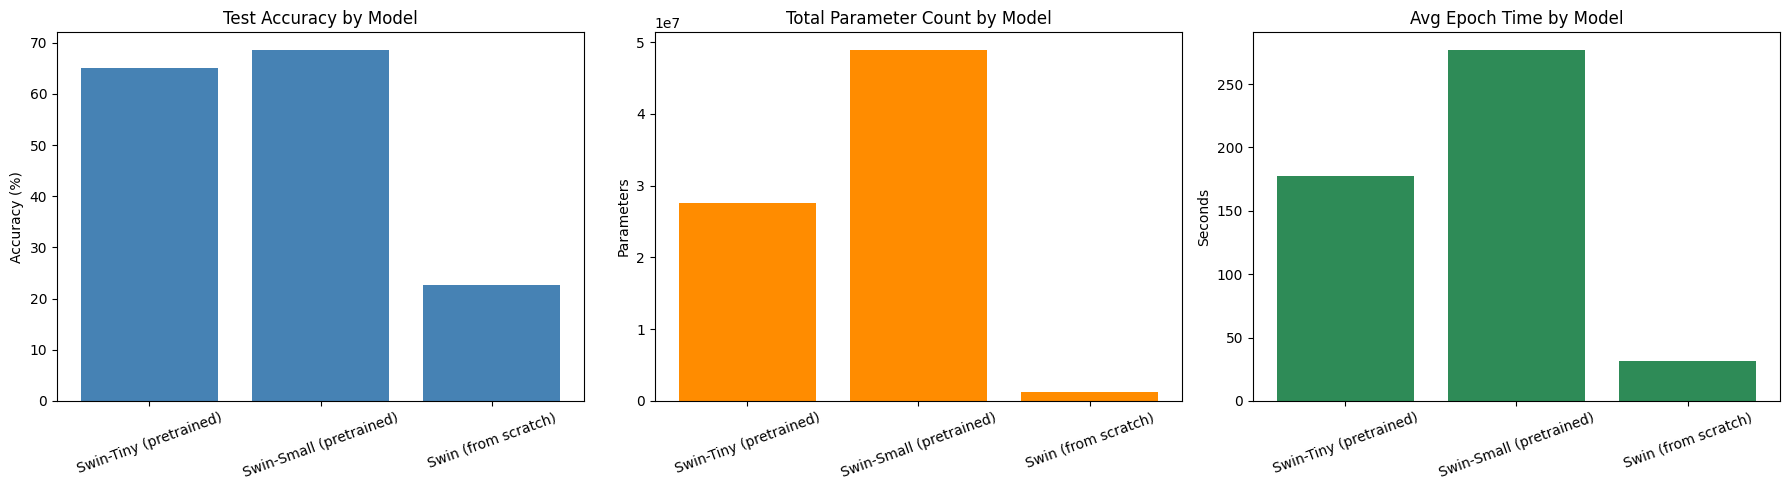

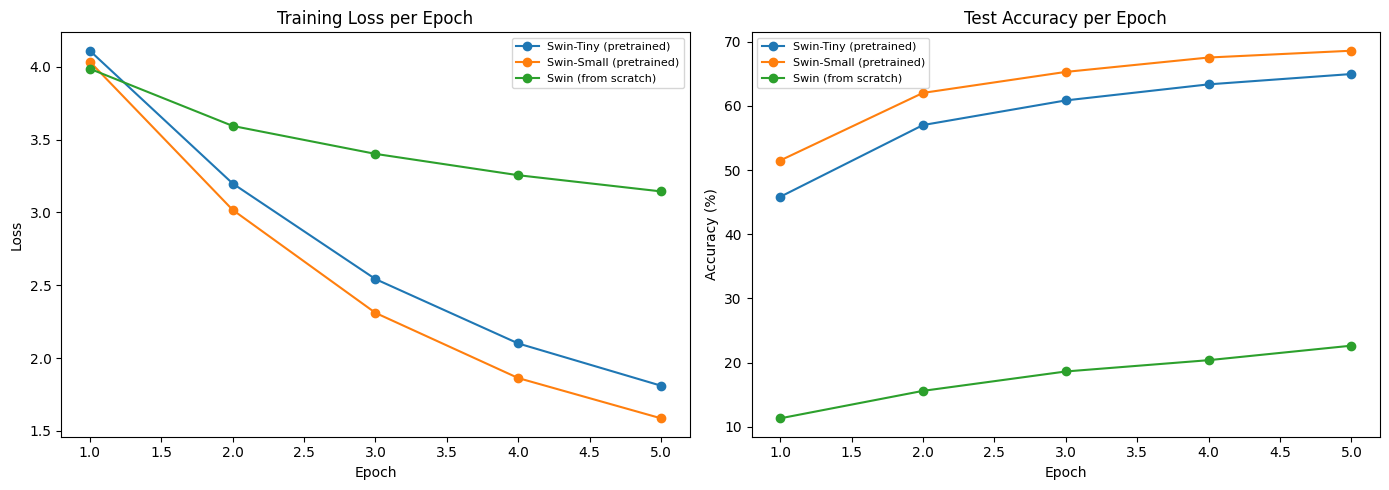

In [10]:
import matplotlib.pyplot as plt

names = list(results.keys())
accs = [results[n]["accuracy"] for n in names]
total_params_list = [results[n]["total_params"] for n in names]
times = [results[n]["avg_epoch_time"] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(names, accs, color="steelblue")
axes[0].set_title("Test Accuracy by Model")
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, total_params_list, color="darkorange")
axes[1].set_title("Total Parameter Count by Model")
axes[1].set_ylabel("Parameters")
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(names, times, color="seagreen")
axes[2].set_title("Avg Epoch Time by Model")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("swin_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n in names:
    h = results[n]["history"]
    axes[0].plot(h["epoch"], h["train_loss"], marker="o", label=n)
    axes[1].plot(h["epoch"], h["test_acc"], marker="o", label=n)

axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=8)
axes[1].set_title("Test Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("swin_curves.png", dpi=150, bbox_inches="tight")
plt.show()
